# 1er Pracial
* Univ: Moises Adbel Andres Torrez Huarina
* Materia: INF-672 MACHINE LEARNING
* Fecha: 16/09/2026

# EJERCICIO 01 Una probabilidad de dos maneras: contar y simular
El evento es: «sacar al menos un 6 al tirar dos dados». Lo vas a calcular de forma exacta y luego estimarlo
simulando, para comprobar que coinciden.
De ambos dados al menos un dado debe de sacar 6 asi que se podria tener las siguientes combinaciones (6,1)(6,2)(6,3)(6,4)(6,5)(6,6)(1,6)(2,6)(3,6)(4,6)(5,6) en total son 11 combinaciones de 36 donde se cumple el evento

In [1]:
#cargamos las librerias
import itertools
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Valor exacto por conteo

In [2]:
combinaciones= list(itertools.product(range(1, 7), repeat=2))
combinacion_con_6=[]
for x in combinaciones:
    if 6 in x:
        combinacion_con_6.append(x)
prob_exacta = len(combinacion_con_6) / len(combinaciones)
print("Total de combinaciones existentes",len(combinaciones))
print("Combinaciones donde almenos hay un 6",combinacion_con_6,"\n en total son: ",len(combinacion_con_6))
print("Probabilidad de sacar al menos un 6 :",prob_exacta )

Total de combinaciones existentes 36
Combinaciones donde almenos hay un 6 [(1, 6), (2, 6), (3, 6), (4, 6), (5, 6), (6, 1), (6, 2), (6, 3), (6, 4), (6, 5), (6, 6)] 
 en total son:  11
Probabilidad de sacar al menos un 6 : 0.3055555555555556


# 2. Estimación por simulación

In [3]:
gna = np.random.default_rng(42) #Generador de numeros aleatorios

def probabilidad(x):
    tiradas = gna.integers(1, 7, size=(x, 2))
    tiene_6 = np.any(tiradas == 6, axis=1)
    return tiene_6.mean()

valores = [100, 1000, 100000]
resultados = []
for x in valores:
    estimacion = probabilidad(x)
    error = abs(estimacion - prob_exacta)
    resultados.append((x, estimacion, error))

tabla = pd.DataFrame(resultados, columns=['N', 'Estimación', 'Error absoluto'])
tabla['Valor exacto'] = prob_exacta
tabla


,N,Estimación,Error absoluto,Valor exacto
0,100,0.24000,0.065556,0.305556
1,1000,0.31000,0.004444,0.305556
2,100000,0.30583,0.000274,0.305556


**¿Cuál se acercó más y por qué?**

Una estimacion con X=100000 es la ms cercana a la probabilidad real , con un sesgo minimo
que los anteriores numeros de estimaciones, eso explica que : cuantas mas repeticiones mas se acerca
al promedio

**¿Qué le pasa a la estimación con pocas tiradas?**

Se vuelve inestable con x=100 el resultado queda notablemente lejos del valor 
real, y variaría si se repitiera la simulación con otra semilla. A medida que N 
crece, esa variabilidad disminuye

# Grafico de convergencia

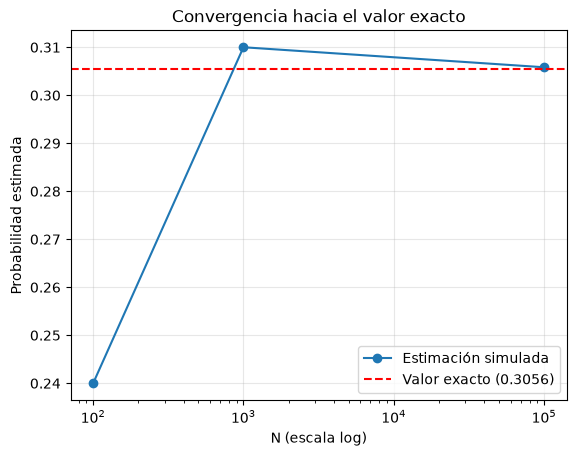

In [4]:
plt.plot(valores, [r[1] for r in resultados], marker='o', label='Estimación simulada')
plt.axhline(prob_exacta, color='red', linestyle='--', label=f'Valor exacto ({prob_exacta:.4f})')
plt.xscale('log')
plt.xlabel('N (escala log)')
plt.ylabel('Probabilidad estimada')
plt.title('Convergencia hacia el valor exacto')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# EJERCICIO 02 Perfil estadístico por especie y limpieza de datos
Se trabaja con el dataset Iris, que contiene mediciones de 150 flores repartidas en 3 especies (setosa, versicolor, virginica), con 4 medidas por flor: largo y ancho de sépalo, largo y ancho de pétalo

Vas a describir con números las tres especies de Iris y a dejar la tabla lista para un modelo.

In [5]:
# Cargamos el dataset
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
diccionario_especies = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
df['species'] = df['target'].map(diccionario_especies)
df=df.drop(columns='target')
df.head(50)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


# 1. Perfil por especie
Se trabaja con el dataset Iris, que contiene mediciones de 150 flores repartidas en 3 especies (setosa, versicolor, virginica), con 4 medidas por flor: largo y ancho de sépalo, largo y ancho de pétalo,Carga Iris con la columna de especie, agrupa con groupby('species') y calcula, para
las cuatro características, la media, la mediana, la desviación estándar y los cuartiles (Q1, Q2, Q3).
Preséntalo en una tabla legible.

In [6]:
perfil = df.groupby('species').agg([
    'mean', 'median', 'std',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.50),
    lambda x: x.quantile(0.75)
])
perfil.columns = perfil.columns.set_levels(
    ['media', 'mediana', 'desviacion', 'Q1', 'Q2', 'Q3'], level=1
)
perfil

sepal length (cm)                                      \
                       media mediana desviacion     Q1   Q2   Q3   
species                                                            
setosa                 5.006     5.0   0.352490  4.800  5.0  5.2   
versicolor             5.936     5.9   0.516171  5.600  5.9  6.3   
virginica              6.588     6.5   0.635880  6.225  6.5  6.9   

           sepal width (cm)                            ... petal length (cm)  \
                      media mediana desviacion     Q1  ...        desviacion   
species                                                ...                     
setosa                3.428     3.4   0.379064  3.200  ...          0.173664   
versicolor            2.770     2.8   0.313798  2.525  ...          0.469911   
virginica             2.974     3.0   0.322497  2.800  ...          0.551895   

                             petal width (cm)                               \
             Q1    Q2     Q3            media mediana desviacion   Q1   Q2   
species                                                                      
setosa      1.4  1.50  1.575            0.246     0.2   0.105386  0.2  0.2   
versicolor  4.0  4.35  4.600            1.326     1.3   0.197753  1.2  1.3   
virginica   5.1  5.55  5.875            2.026     2.0   0.274650  1.8  2.0   

                 
             Q3  
species          
setosa      0.3  
versicolor  1.5  
virginica   2.3  

[3 rows x 24 columns]

# 2. Faltantes. 
Agrega unos pocos np.nan (con semilla fija), cuéntalos por columna con df.isna().sum() e
imputa los huecos con la mediana de cada columna por especie. Explica por qué se prefiere la
mediana a la media.

In [7]:
rng = np.random.default_rng(0)
df_nan = df.copy()
columnas_numericas = df.columns[:-1]

for _ in range(10):
    fila = rng.integers(0, len(df_nan))
    columna = rng.choice(columnas_numericas)
    df_nan.loc[fila, columna] = np.nan

df_nan.isna().sum()

sepal length (cm)    2
sepal width (cm)     1
petal length (cm)    4
petal width (cm)     3
species              0
dtype: int64

In [8]:
df_imputado = df_nan.copy()
for columna in columnas_numericas:
    df_imputado[columna] = df_imputado.groupby('species')[columna].transform(
        lambda x: x.fillna(x.median())
    )

df_imputado.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

la mediana puede cambiar hacia un extremo en base a las medidas que se hicieron , por otro lado la media es exactamente la mitad la cual no cambiara y ademas habra un menor riesgo de sesgos al trabajar con datos

# Lectura.
Mirando la tabla de medias por especie, indica qué característica parece separar mejor las tres
especies y cuál las confunde.

El largo del petalo es el la caracteristica que mejor separa entre las especies debido a que hay una diferecia de 4 cm pasando por unas medidas de 5cm a 1.4cm
por otro lado en ancho del sepalo es la que mas confunde por sus medidas que son parecidas

# ¿por qué una característica con medias muy distintas entre especies separa mejor que una con medias parecidas?
Por que ese rango entre difirentes medidas nos permite separar las especies, cada medida es importante por que podremos identificar a que grupo puede pertencer incluso es mejor si tenemos mas datos para evitar los sesgo en medidas parecidas las cuales no te permiten distingir cada especie

# EJERCICIO 03 Tres formas de comparar dos flores, hechas por ti
Vas a programar desde cero las tres operaciones con las que se mide qué tan parecidas son dos flores,
usando solo NumPy

In [9]:
# Cragamos Dataset
iris = load_iris()
X = iris.data
y = iris.target
def dist_euclidiana(a, b):
    return np.sqrt(np.sum((a - b) ** 2))
def producto_punto(a, b):
    return np.sum(a * b)
def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))    
i1, i2 = 0, 1
i3, i4 = 50, 100
print(f"Flor {i1}: especie {y[i1]} ({iris.target_names[y[i1]]})")
print(f"Flor {i2}: especie {y[i2]} ({iris.target_names[y[i2]]})")
print(f"Flor {i3}: especie {y[i3]} ({iris.target_names[y[i3]]})")
print(f"Flor {i4}: especie {y[i4]} ({iris.target_names[y[i4]]})")
pares = [(i1, i2, "misma especie"), (i3, i4, "especies distintas")]
resultados = []
for x_a, x_b, tipo in pares:
    a, b = X[x_a], X[x_b]
    resultados.append({
        "Par": f"flor {x_a} - flor {x_b}",
        "Tipo": tipo,
        "Distancia euclidiana": dist_euclidiana(a, b),
        "Producto punto": producto_punto(a, b),
        "Similitud coseno": similitud_coseno(a, b)
    })
display(pd.DataFrame(resultados))

Flor 0: especie 0 (setosa)
Flor 1: especie 0 (setosa)
Flor 50: especie 1 (versicolor)
Flor 100: especie 2 (virginica)


,Par,Tipo,Distancia euclidiana,Producto punto,Similitud coseno
0,flor 0 - flor 1,misma especie,0.538516,37.49,0.998579
1,flor 50 - flor 100,especies distintas,1.843909,86.36,0.982137


**¿las flores de la misma especie
salieron «más parecidas» (menor distancia, mayor coseno)?**

Sí porque las flores de la misma especie comparten proporciones y tamaños casi idénticos.Esto hace que sus diferencias sean mínimas y sus vectores apunten en la misma dirección, lo que se traduce en una distancia euclidiana muy cercana a cero y en una similitud coseno muy cercana a uno confirmando que casi no hay separación ni diferencia de ángulo entre ellas

**¿La distancia euclidiana y la similitud
coseno ordenan las flores igual?**

No necesariamente porque miden aspectos geométricos diferentes. La distancia euclidiana evalúa la diferencia de tamaño absoluto calculando la distancia en línea recta entre puntos, mientras que la similitud coseno evalúa únicamente la proporción, dos flores con exactamente la misma forma pero de tamaños muy distintos tendrán una distancia euclidiana alta y un coseno perfecto, lo que puede cambiar el orden de similitud entre diferentes pares.

# EJERCICIO 04 Bajar la colina: descenso de gradiente
Muchos modelos aprenden buscando el punto más bajo de una función de error. Aquí lo haces sobre una
función sencilla cuyo mínimo ya conoces: $$f(x) = (x - 4)^2 + 1$$ una parábola con mínimo en x = 4. Usa su
derivada, que se te da:$$f'(x) = 2 \cdot (x - 4)$$

In [10]:
x_inicial = 10.0
pasos = 30
tasas = [0.01, 0.1, 1.1]
trayectorias = {}
def f(x):
    return (x - 4)**2 + 1
def devf(x):
    return 2*(x - 4)
def descenso_gradiente(x0, tasa, pasos):
    x = x0
    trayectoria = [x]
    for _ in range(pasos):
        x = x - tasa * devf(x)
        trayectoria.append(x)
    return trayectoria
    
for tasa in tasas:
    trayectorias[tasa] = descenso_gradiente(x0=x_inicial, tasa=tasa, pasos=pasos)
    print(f"Tasa {tasa}: x final = {trayectorias[tasa][-1]:.4f}")

Tasa 0.01: x final = 7.2729
Tasa 0.1: x final = 4.0074
Tasa 1.1: x final = 1428.2579


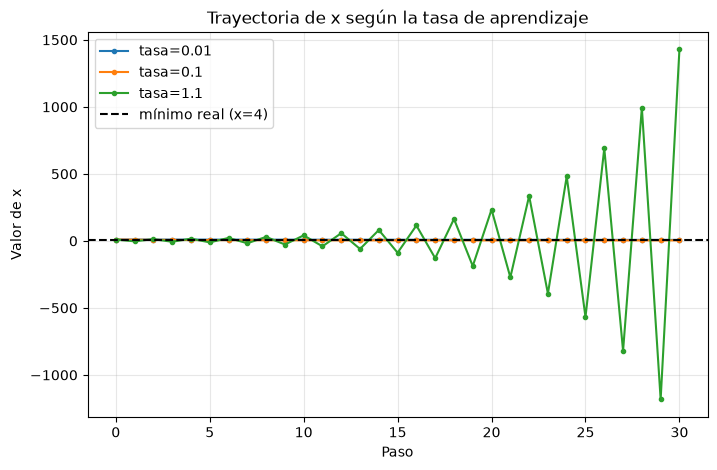

In [11]:
plt.figure(figsize=(8, 5))
for tasa in tasas:
    plt.plot(trayectorias[tasa], marker='o', markersize=3, label=f'tasa={tasa}')

plt.axhline(4, color='black', linestyle='--', label='mínimo real (x=4)')
plt.xlabel('Paso')
plt.ylabel('Valor de x')
plt.title('Trayectoria de x según la tasa de aprendizaje')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**¿Todas llegan cerca del mínimo?**

No. Solo la tasa intermedia ($\alpha = 0.1$) logra converger de manera rápida y precisa cerca del mínimo verdadero ($x = 4$). La tasa pequeña requiere muchos más pasos para acercarse, mientras que la tasa grande nunca llega porque diverge

**¿Qué pasa con la tasa muy pequeña ($\alpha = 0.01$)**

Avanza extremadamente lento. Al multiplicar la derivada por un número tan pequeño, los pasos de actualización son diminutos, lo que exige una gran cantidad de iteraciones para poder aproximarse al punto más bajo de la curva

**¿Qué pasa con la tasa muy grande ($\alpha = 1.1$)?**

Se dispara y diverge. Al dar un paso excesivamente grande, el algoritmo salta al otro lado de la parábola pero a una altura mayor, lo que genera oscilaciones que crecen de forma exponencial en cada iteración en lugar de reducirse